# --- FROM NOTEBOOK: 01_data_loading_inspection.ipynb ---

# 01 — Data Loading & Inspection
---
**Purpose:** Locate and safely load all 2022–2025 F1 lap data. Inspect schemas, standardize team names, preserve raw data, and perform initial dataset diagnostics.

**Output:** `outputs/combined_laps.parquet`

In [1]:
import pandas as pd
import numpy as np
import os, glob, warnings
warnings.filterwarnings("ignore")

DATA_DIR = os.path.join("..", "data_fastf1_v1", "laps")
OUTPUT_DIR = os.path.join("..", "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEASONS = [2022, 2023, 2024, 2025]
print("Setup complete. Output directory ready.")

Setup complete. Output directory ready.


## 1. Locate Datasets & Inspect Schemas

In [2]:
all_schemas = {}
file_counts = {}
all_files = []

for season in SEASONS:
    season_dir = os.path.join(DATA_DIR, str(season))
    count = 0
    for csv_file in sorted(glob.glob(os.path.join(season_dir, "*.csv"))):
        fname = os.path.basename(csv_file)
        hdr = pd.read_csv(csv_file, nrows=0)
        all_schemas[f"{season}/{fname}"] = set(hdr.columns)
        all_files.append(csv_file)
        count += 1
    file_counts[season] = count
    print(f"  {season}: {count} files located.")

unique_sets = {}
for key, cols in all_schemas.items():
    frozen = frozenset(cols)
    unique_sets.setdefault(frozen, []).append(key)

print(f"\nTotal files: {len(all_files)}")
print(f"Distinct schemas found: {len(unique_sets)}")
if len(unique_sets) == 1:
    ref_cols = list(list(unique_sets.keys())[0])
    print(f"[OK] Schema is 100% consistent. All {len(all_files)} files share the exact same {len(ref_cols)}-column schema.")
else:
    print("[WARNING] Schema differences detected!")

  2022: 22 files located.


  2023: 22 files located.


  2024: 24 files located.


  2025: 24 files located.

Total files: 92
Distinct schemas found: 1
[OK] Schema is 100% consistent. All 92 files share the exact same 65-column schema.


## 2. Bahrain Demo Dataset Comparison

In [3]:
demo_path = os.path.join(DATA_DIR, "2024", "Bahrain_Grand_Prix.csv")
if os.path.exists(demo_path):
    demo_df = pd.read_csv(demo_path)
    print(f"Bahrain 2024 Demo Dataset:")
    print(f"  Rows: {len(demo_df):,}")
    print(f"  Cols: {len(demo_df.columns)}")
    
    # Pick a random other file to compare
    other_path = os.path.join(DATA_DIR, "2023", "Monaco_Grand_Prix.csv")
    other_df = pd.read_csv(other_path)
    
    print(f"\nComparison with Monaco 2023:")
    print(f"  Columns match? {set(demo_df.columns) == set(other_df.columns)}")
    
    demo_types = demo_df.dtypes.to_dict()
    other_types = other_df.dtypes.to_dict()
    type_diff = {k: (demo_types[k], other_types[k]) for k in demo_types if demo_types[k] != other_types[k]}
    
    if not type_diff:
        print("  Data types match 100% between the files.")
    else:
        print(f"  Type differences detected: {type_diff}")
else:
    print("Bahrain 2024 Demo file not found.")

Bahrain 2024 Demo Dataset:
  Rows: 1,129
  Cols: 65



Comparison with Monaco 2023:
  Columns match? True
  Type differences detected: {'IsPersonalBest': (dtype('bool'), dtype('O'))}


## 3. Load All Data (Safely)

In [4]:
all_dfs = []
for f in all_files:
    # Read without assuming types to avoid inference errors, then we'll cast
    all_dfs.append(pd.read_csv(f))

df = pd.concat(all_dfs, ignore_index=True)
print(f"Combined dataset loaded: {len(df):,} laps x {len(df.columns)} columns")
print(f"Memory footprint: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Combined dataset loaded: 101,290 laps x 65 columns
Memory footprint: 78.4 MB


## 4. Duplicate Check

In [5]:
duplicates = df.duplicated().sum()
if duplicates == 0:
    print("[OK] Zero exact duplicate rows found across the entire dataset.")
else:
    print(f"[WARNING] Found {duplicates:,} duplicate rows!")

[OK] Zero exact duplicate rows found across the entire dataset.


## 5. Type Summaries & Casting

In [6]:
numeric_cols = [
    "LapNumber", "Stint", "TyreLife", "Position",
    "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST",
    "AirTemp", "Humidity", "Pressure", "TrackTemp", "WindSpeed",
    "LapTimeSeconds", "PitInTimeSeconds", "PitOutTimeSeconds",
    "Sector1TimeSeconds", "Sector2TimeSeconds", "Sector3TimeSeconds",
    "TimeSeconds", "LapStartTimeSeconds",
    "GapToLeaderSeconds", "IntervalToPositionAheadSeconds",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

bool_cols = [
    "IsPersonalBest", "FreshTyre", "Deleted", "FastF1Generated",
    "IsAccurate", "Rainfall", "HasGreen", "HasYellow",
    "HasSafetyCar", "HasRedFlag", "HasVSC", "HasVSCEnding",
]
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(bool)

print("Type casting complete. Summary of Data Types:")
type_counts = df.dtypes.value_counts()
for dtype, count in type_counts.items():
    print(f"  {dtype}: {count} columns")

Type casting complete. Summary of Data Types:
  float64: 27 columns
  str: 20 columns
  bool: 12 columns
  int64: 5 columns
  object: 1 columns


## 6. Standardize Schema Inconsistencies

In [7]:
# 1. Drop dead column
dead_cols = [col for col in df.columns if df[col].isna().all()]
print(f"Fully null columns: {dead_cols}")
if "LapStartDate" in df.columns:
    df = df.drop(columns=["LapStartDate"])
    print("Dropped: LapStartDate")

# 2. Create RaceId
df["RaceId"] = df["Year"].astype(str) + "_" + df["GrandPrix"].str.replace(" ", "_")

# 3. Canonical Team Mapping
TEAM_MAPPING = {
    "Alfa Romeo": "Sauber", "Kick Sauber": "Sauber",
    "AlphaTauri": "VCARB", "RB": "VCARB", "Racing Bulls": "VCARB",
    "Alpine": "Alpine", "Aston Martin": "Aston Martin",
    "Ferrari": "Ferrari", "Haas F1 Team": "Haas",
    "McLaren": "McLaren", "Mercedes": "Mercedes",
    "Red Bull Racing": "Red Bull", "Williams": "Williams",
}
df["CanonicalTeam"] = df["Team"].map(TEAM_MAPPING)

print("\nStandardization complete. (Raw data preserved, mapping added).")

Fully null columns: ['LapStartDate']
Dropped: LapStartDate

Standardization complete. (Raw data preserved, mapping added).


## 7. Dataset Summary & Counts

In [8]:
print("=" * 60)
print("GLOBAL DATASET SUMMARY")
print("=" * 60)
print(f"  Total laps:       {len(df):,}")
print(f"  Unique races:     {df['RaceId'].nunique()}")
print(f"  Seasons:          {sorted(df['Year'].unique())}")
print(f"  Unique drivers:   {df['Driver'].nunique()}")
print(f"  Canonical teams:  {df['CanonicalTeam'].nunique()} (from {df['Team'].nunique()} raw names)")
print(f"  Unique circuits:  {df['GrandPrix'].nunique()}")
print(f"  Compounds:        {sorted(df['Compound'].dropna().unique())}")

print(f"\nLaps per season:")
for season in SEASONS:
    s = df[df["Year"] == season]
    print(f"  {season}: {len(s):,} laps, {s['RaceId'].nunique()} races")

GLOBAL DATASET SUMMARY
  Total laps:       101,290
  Unique races:     92
  Seasons:          [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
  Unique drivers:   31
  Canonical teams:  10 (from 13 raw names)
  Unique circuits:  25
  Compounds:        ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']

Laps per season:
  2022: 23,577 laps, 22 races


  2023: 24,420 laps, 22 races


  2024: 26,604 laps, 24 races
  2025: 26,689 laps, 24 races


## 8. Missing Value Summary

In [9]:
print(f"{'Column':<45} {'Nulls':>8}  {'%':>6}")
print("-" * 62)
for col in df.columns:
    null_n = df[col].isna().sum()
    if null_n > 0:
        print(f"  {col:<43} {null_n:>8,}  {100*null_n/len(df):>5.1f}%")

Column                                           Nulls       %
--------------------------------------------------------------
  LapTime                                        1,539    1.5%
  Stint                                            354    0.3%
  PitOutTime                                    97,823   96.6%
  PitInTime                                     97,821   96.6%
  Sector1Time                                    2,094    2.1%
  Sector2Time                                      169    0.2%
  Sector3Time                                      282    0.3%
  Sector1SessionTime                             2,317    2.3%
  Sector2SessionTime                               169    0.2%
  Sector3SessionTime                               282    0.3%
  SpeedI1                                          136    0.1%
  SpeedI2                                        1,020    1.0%
  SpeedFL                                        3,602    3.6%
  SpeedST                                          181 

## 9. Save Combined Standardized Dataset

In [10]:
output_path = os.path.join(OUTPUT_DIR, "data", "combined_laps.parquet")
df.to_parquet(output_path, index=False)
fsize = os.path.getsize(output_path) / 1e6
print(f"Saved dataset to: {output_path}")
print(f"File size: {fsize:.1f} MB")
print(f"Shape: {df.shape}")
print("\n[OK] Notebook 01 Data Loading & Inspection complete.")

Saved dataset to: ..\outputs\combined_laps.parquet
File size: 14.4 MB
Shape: (101290, 66)

[OK] Notebook 01 Data Loading & Inspection complete.


# --- FROM NOTEBOOK: 02_data_cleaning.ipynb ---

# 02 — Data Cleaning & Target Preservation
---
**Purpose:** Implement the exact logic from the approved data cleaning specification on the complete 101k lap dataset. Creates diagnostic flags and a final `is_clean` definition. Computes extensive data loss reporting by season, circuit, team, and compound.

**Outputs:** 
- `outputs/cleaned_laps.parquet` (Full dataset with diagnostic flags)
- `outputs/clean_laps.parquet` (Subset where `is_clean == True`)
- `outputs/cleaning_report.csv` (Reporting metrics)

In [1]:
import pandas as pd
import numpy as np
import os, warnings
warnings.filterwarnings("ignore")

OUTPUT_DIR = os.path.join("..", "outputs")
input_path = os.path.join(OUTPUT_DIR, "data", "combined_laps.parquet")

print("Loading dataset...")
df = pd.read_parquet(input_path)
total_raw_laps = len(df)
print(f"Loaded {total_raw_laps:,} laps across {df['RaceId'].nunique()} races.")

Loading dataset...
Loaded 101,290 laps across 92 races.


## 1. Delete Forbidden / Redundant Columns

In [2]:
# Drop string timings since we have _Seconds floats
string_cols = [
    "Time", "LapTime", "PitInTime", "PitOutTime", 
    "Sector1Time", "Sector2Time", "Sector3Time",
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime",
    "LapStartTime"
]
# Drop target leakage columns (Gaps represent the END of the lap)
leakage_cols = [
    "GapToLeader", "IntervalToPositionAhead",
    "GapToLeaderSeconds", "IntervalToPositionAheadSeconds"
]

to_drop = [c for c in string_cols + leakage_cols if c in df.columns]
df = df.drop(columns=to_drop)
print(f"Dropped {len(to_drop)} redundant/leakage columns.")

Dropped 15 redundant/leakage columns.


## 2. Generate Diagnostic Flags

In [3]:
# Using the specific flag names requested where appropriate, and mapping to our logic.

# 1. Missing target
df['flag_missing_target'] = df['LapTimeSeconds'].isna() | (df['LapTimeSeconds'] <= 0)

# 2. Missing crucial tyre data
df['flag_missing_tyre'] = df['Compound'].isna() | df['TyreLife'].isna() | df['Stint'].isna()

# 3. Pit lane interference
df['is_pit_in'] = df['PitInTimeSeconds'].notna()
df['is_pit_out'] = df['PitOutTimeSeconds'].notna()

# 4. Standing starts
df['flag_lap_1'] = df['LapNumber'] == 1

# 5. Non-Dry tyres
df['flag_wet_compound'] = df['Compound'].isin(['INTERMEDIATE', 'WET'])

# 6. Race Control (SC, VSC, Red Flag)
df['is_safety_car'] = df['HasSafetyCar'] == True
df['is_vsc'] = (df['HasVSC'] == True) | (df['HasVSCEnding'] == True)
df['is_red_flag'] = df['HasRedFlag'] == True

# 7. Local Yellow (without green clearing it in the same lap)
df['is_yellow_flag'] = df['HasYellow'] & ~df['HasGreen']

# 8. Unreliable Telemetry/Sensors
df['is_deleted'] = df['Deleted'] == True
df['is_accurate'] = df['IsAccurate'].fillna(True)

# 9. Light Rain on Dry Tyres
df['flag_rainfall'] = df['Rainfall'] == True

# 10. Extreme Outliers (115% of median race/compound pace)
median_pace = df.groupby(['RaceId', 'Compound'])['LapTimeSeconds'].transform('median')
df['flag_outlier'] = (df['LapTimeSeconds'] > (median_pace * 1.15)) & df['LapTimeSeconds'].notna()

# Collect all exclusionary flags (Note: is_accurate is positive, so we invert it for exclusion)
exclusion_flags = [
    'flag_missing_target', 'flag_missing_tyre', 'is_pit_in', 'is_pit_out',
    'flag_lap_1', 'flag_wet_compound', 'is_safety_car', 'is_vsc', 'is_red_flag',
    'is_yellow_flag', 'is_deleted', 'flag_rainfall', 'flag_outlier'
]

# Create inverted accurate flag for the sum
df['flag_inaccurate'] = ~df['is_accurate']
exclusion_flags.append('flag_inaccurate')

print("Flags generated successfully.")

Flags generated successfully.


## 3. Data Loss Analysis & Reporting

In [4]:
# Overall loss by flag
report_data = []
print(f"{'Flag Reason':<25} {'Laps Excluded':>15} {'% of Total':>12}")
print("-" * 55)
for flag in exclusion_flags:
    count = df[flag].sum()
    pct = (count / total_raw_laps) * 100
    report_data.append({'Metric': flag, 'Category': 'Overall', 'Laps_Excluded': count, 'Percentage': pct})
    print(f"{flag:<25} {count:>15,} {pct:>11.1f}%")

df['is_clean_lap'] = ~df[exclusion_flags].any(axis=1)
clean_count = df['is_clean_lap'].sum()
overall_retention = (clean_count / total_raw_laps) * 100
report_data.append({'Metric': 'Total_Clean', 'Category': 'Overall', 'Laps_Excluded': total_raw_laps - clean_count, 'Percentage': overall_retention})

print(f"\nTotal Raw Laps:   {total_raw_laps:,}")
print(f"Total Clean Laps: {clean_count:,}")
print(f"Clean Retention:  {overall_retention:.1f}%")

Flag Reason                 Laps Excluded   % of Total
-------------------------------------------------------
flag_missing_target                 1,539         1.5%
flag_missing_tyre                   1,055         1.0%
is_pit_in                           3,469         3.4%
is_pit_out                          3,467         3.4%
flag_lap_1                          1,826         1.8%
flag_wet_compound                   6,406         6.3%
is_safety_car                       5,365         5.3%
is_vsc                              2,012         2.0%
is_red_flag                           224         0.2%
is_yellow_flag                        516         0.5%
is_deleted                          1,273         1.3%
flag_rainfall                       4,011         4.0%
flag_outlier                        7,520         7.4%
flag_inaccurate                    13,768        13.6%

Total Raw Laps:   101,290
Total Clean Laps: 79,865
Clean Retention:  78.8%


## 4. Dimensional Reporting

In [5]:
def analyze_dimension(dim_col):
    res = df.groupby(dim_col).agg(
        Total_Laps=('LapNumber', 'count'),
        Clean_Laps=('is_clean_lap', 'sum')
    )
    res['Retention_Pct'] = (res['Clean_Laps'] / res['Total_Laps']) * 100
    res['Loss_Pct'] = 100 - res['Retention_Pct']
    return res

dimensions = ['Year', 'GrandPrix', 'CanonicalTeam', 'Compound']

for dim in dimensions:
    if dim in df.columns:
        res = analyze_dimension(dim)
        print(f"\n--- Retention by {dim} ---")
        print(res[['Total_Laps', 'Clean_Laps', 'Retention_Pct']].sort_values('Retention_Pct'))
        
        # Add to report
        for idx, row in res.iterrows():
            report_data.append({
                'Metric': str(idx),
                'Category': dim,
                'Laps_Excluded': row['Total_Laps'] - row['Clean_Laps'],
                'Percentage': row['Loss_Pct']
            })

report_df = pd.DataFrame(report_data)
report_out = os.path.join(OUTPUT_DIR, "reports", "cleaning_report.csv")
report_df.to_csv(report_out, index=False)
print(f"\nSaved extensive report to {report_out}")


--- Retention by Year ---
      Total_Laps  Clean_Laps  Retention_Pct
Year                                       
2022       23577       17225      73.058489
2025       26689       21339      79.954288
2024       26604       21280      79.987972
2023       24420       20021      81.986077

--- Retention by GrandPrix ---
                           Total_Laps  Clean_Laps  Retention_Pct
GrandPrix                                                       
British Grand Prix               3571        2093      58.611033
Australian Grand Prix            3973        2473      62.245155
São Paulo Grand Prix             4752        2961      62.310606
Canadian Grand Prix              5202        3600      69.204152
Monaco Grand Prix                5356        3856      71.994025
Japanese Grand Prix              3353        2448      73.009245
Dutch Grand Prix                 5525        4210      76.199095
Belgian Grand Prix               3328        2541      76.352163
Singapore Grand Prix       


Saved extensive report to ..\outputs\cleaning_report.csv


## 5. Save Datasets

In [6]:
# 1. Full processed dataset (with flags)
cleaned_out = os.path.join(OUTPUT_DIR, "data", "cleaned_laps.parquet")
df.to_parquet(cleaned_out, index=False)
print(f"Saved complete processed dataset to: {cleaned_out} ({(os.path.getsize(cleaned_out)/1e6):.1f} MB)")

# 2. Subset for tyre modelling (only clean laps)
clean_subset_out = os.path.join(OUTPUT_DIR, "clean_laps.parquet")
clean_df = df[df['is_clean_lap']].copy()
# Drop flags since they are all False in this subset to save space
cols_to_drop = exclusion_flags + ['is_clean_lap', 'is_accurate']
clean_df = clean_df.drop(columns=[c for c in cols_to_drop if c in clean_df.columns])
clean_df.to_parquet(clean_subset_out, index=False)
print(f"Saved clean-lap subset to: {clean_subset_out} ({(os.path.getsize(clean_subset_out)/1e6):.1f} MB)")

print("\n[OK] Notebook 02 Data Cleaning complete.")

Saved complete processed dataset to: ..\outputs\cleaned_laps.parquet (6.6 MB)


Saved clean-lap subset to: ..\outputs\clean_laps.parquet (5.0 MB)

[OK] Notebook 02 Data Cleaning complete.


# --- FROM NOTEBOOK: 04_tyre_stint_processing.ipynb ---

# 04 — Tyre Stint Processing
---
**Purpose:** Reconstruct tyre sequences, define globally unique `StintId`s, independently calculate `StintLap` (phase of the stint) vs `TyreLife` (physical age), and resolve telemetry dropouts.

**Input:** `outputs/cleaned_laps.parquet` (Full race sequence with flags)
**Outputs:** 
- `outputs/tyre_stints.parquet`
- `outputs/stint_quality_report.csv`
- `outputs/plots/tyre_life_distribution.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")

OUTPUT_DIR = os.path.join("..", "outputs")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)
input_path = os.path.join(OUTPUT_DIR, "data", "cleaned_laps.parquet")

print("Loading dataset...")
df = pd.read_parquet(input_path)
print(f"Loaded {len(df):,} laps.")

Loading dataset...
Loaded 101,290 laps.


## 1. Sort & Forward-Fill Telemetry Dropouts

In [2]:
# Sort strictly chronologically per driver
df = df.sort_values(['Year', 'Round', 'Driver', 'LapNumber'])

# Forward-fill Stint, TyreLife, Compound within Race & Driver to bridge 1-lap dropouts
cols_to_fill = ['Stint', 'TyreLife', 'Compound']
for col in cols_to_fill:
    df[col] = df.groupby(['RaceId', 'Driver'])[col].ffill(limit=1)

print(f"Missing values remaining after ffill:")
for col in cols_to_fill:
    print(f"  {col}: {df[col].isna().sum()}")

Missing values remaining after ffill:
  Stint: 354
  TyreLife: 948
  Compound: 762


## 2. Define Unique Stints & StintLap

In [3]:
# Stint counter resets per race/driver, so we create a global ID
df['StintId'] = df['RaceId'].astype(str) + '_' + df['Driver'] + '_S' + df['Stint'].astype(str)
df.loc[df['Stint'].isna(), 'StintId'] = np.nan

# StintLap: Sequential counter within the StintId (phase of the stint)
df['StintLap'] = df.groupby('StintId').cumcount() + 1
df.loc[df['StintId'].isna(), 'StintLap'] = np.nan

# Preserve original TyreLife, but also assign it to TyreAge as requested
df['TyreAge'] = df['TyreLife']

# TyreChangeFlag
df['PrevStintId'] = df.groupby(['RaceId', 'Driver'])['StintId'].shift(1)
df['TyreChangeFlag'] = (df['StintId'] != df['PrevStintId']) & df['PrevStintId'].notna() & df['StintId'].notna()
df = df.drop(columns=['PrevStintId'])

print("Globally unique StintId, StintLap, TyreAge, and TyreChangeFlag created.")

Globally unique StintId, StintLap, TyreAge, and TyreChangeFlag created.


## 3. Stint Quality Flagging

In [4]:
# A stint needs at least 3 valid racing laps to establish a baseline.
clean_laps_per_stint = df.groupby('StintId')['is_clean_lap'].transform('sum')
# 1 = Good Stint, 0 = Bad Stint (e.g., short stints < 3 clean laps)
df['StintQualityFlag'] = np.where(clean_laps_per_stint >= 3, 1, 0)
df.loc[df['StintId'].isna(), 'StintQualityFlag'] = 0

good_stints = df[df['StintQualityFlag'] == 1]['StintId'].nunique()
bad_stints = df[df['StintQualityFlag'] == 0]['StintId'].nunique() - 1 # exclude NaN
print(f"Identified {good_stints:,} high-quality stints and {bad_stints:,} short/low-quality stints.")

Identified 4,138 high-quality stints and 1,044 short/low-quality stints.


## 4. Rigorous Data Quality Validation

In [5]:
# 1. Unique Compound per Stint
compound_check = df.groupby('StintId')['Compound'].nunique()
if compound_check.max() > 1:
    print("[WARNING] Found a StintId containing multiple compounds!")
else:
    print("[OK] All StintIds contain exactly 1 compound.")

# 2. StintLap starts at 1
min_stintlap = df.dropna(subset=['StintId']).groupby('StintId')['StintLap'].min()
if min_stintlap.max() > 1:
    print("[WARNING] StintLap does not start at 1 for all stints!")
else:
    print("[OK] StintLap correctly starts at 1.")

# 3. TyreLife Monotonicity
tyrelife_diff = df.groupby('StintId')['TyreLife'].diff()
non_monotonic = df[tyrelife_diff < 0]
if len(non_monotonic) > 0:
    print(f"[WARNING] Found {len(non_monotonic)} laps where TyreLife decreased within a stint!")
else:
    print("[OK] TyreLife is perfectly monotonic within all stints.")

[OK] All StintIds contain exactly 1 compound.
[OK] StintLap correctly starts at 1.
[OK] TyreLife is perfectly monotonic within all stints.


## 5. Diagnostic Reporting (Quality by Dimension)

In [6]:
report_data = []
def report_dimension(dim_col):
    stint_level = df.dropna(subset=['StintId']).groupby([dim_col, 'StintId'])['StintQualityFlag'].first().reset_index()
    res = stint_level.groupby(dim_col).agg(
        Total_Stints=('StintId', 'count'),
        Good_Stints=('StintQualityFlag', 'sum')
    )
    res['Quality_Pct'] = (res['Good_Stints'] / res['Total_Stints']) * 100
    return res

dimensions = ['Year', 'GrandPrix', 'CanonicalTeam', 'Compound']

for dim in dimensions:
    if dim in df.columns:
        res = report_dimension(dim)
        print(f"\n--- Stint Quality by {dim} ---")
        print(res.sort_values('Quality_Pct', ascending=False).head(10))
        for idx, row in res.iterrows():
            report_data.append({
                'Dimension': dim,
                'Value': str(idx),
                'Total_Stints': row['Total_Stints'],
                'Good_Stints': row['Good_Stints'],
                'Quality_Pct': row['Quality_Pct']
            })

report_df = pd.DataFrame(report_data)
report_out = os.path.join(OUTPUT_DIR, "reports", "stint_quality_report.csv")
report_df.to_csv(report_out, index=False)
print(f"\nSaved quality report to {report_out}")


--- Stint Quality by Year ---
      Total_Stints  Good_Stints  Quality_Pct
Year                                        
2024          1300         1054    81.076923
2023          1348         1072    79.525223
2025          1295         1029    79.459459
2022          1240          983    79.274194



--- Stint Quality by GrandPrix ---
                          Total_Stints  Good_Stints  Quality_Pct
GrandPrix                                                       
Spanish Grand Prix                 271          267    98.523985
French Grand Prix                   45           44    97.777778
Bahrain Grand Prix                 273          266    97.435897
United States Grand Prix           196          189    96.428571
Abu Dhabi Grand Prix               203          195    96.059113
Miami Grand Prix                   171          164    95.906433
Chinese Grand Prix                 105          100    95.238095
Hungarian Grand Prix               227          216    95.154185
Saudi Arabian Grand Prix           159          149    93.710692
Italian Grand Prix                 180          167    92.777778

--- Stint Quality by CanonicalTeam ---
               Total_Stints  Good_Stints  Quality_Pct
CanonicalTeam                                        
Alpine                  495         


--- Stint Quality by Compound ---
              Total_Stints  Good_Stints  Quality_Pct
Compound                                            
HARD                  1752         1592    90.867580
MEDIUM                1997         1801    90.185278
SOFT                   959          745    77.685089
INTERMEDIATE           424            0     0.000000
WET                     51            0     0.000000

Saved quality report to ..\outputs\stint_quality_report.csv


## 6. Diagnostic Plots

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df[df['StintQualityFlag']==1], x='TyreLife', hue='Compound', bins=30, multiple='stack')
plt.title('TyreLife Distribution in High-Quality Stints')
plt.xlabel('Physical Tyre Age (Laps)')
plt.ylabel('Lap Count')
plot_path = os.path.join(PLOT_DIR, 'tyre_life_distribution.png')
plt.savefig(plot_path)
plt.close()
print(f"Saved diagnostic plot to {plot_path}")

Saved diagnostic plot to ..\outputs\plots\tyre_life_distribution.png


## 7. Save Processed Stints

In [8]:
out_path = os.path.join(OUTPUT_DIR, "data", "tyre_stints.parquet")
df.to_parquet(out_path, index=False)
fsize = os.path.getsize(out_path) / 1e6
print(f"Saved stint dataset to: {out_path}")
print(f"File size: {fsize:.1f} MB")
print("\n[OK] Notebook 04 Tyre Stint Processing complete.")

Saved stint dataset to: ..\outputs\tyre_stints.parquet
File size: 6.7 MB

[OK] Notebook 04 Tyre Stint Processing complete.


# --- FROM NOTEBOOK: 05_feature_engineering.ipynb ---

# 05 — Feature Engineering & Performance Normalization
---
**Purpose:** Implement the approved feature engineering architecture. Constructs the causal target residual (`Target_Tyre_Degradation`), builds tyre state transformations, and calculates lagged rolling trends strictly without future leakage.

**Input:** `outputs/tyre_stints.parquet`
**Output:** `outputs/features_engineered.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")

OUTPUT_DIR = os.path.join("..", "outputs")
input_path = os.path.join(OUTPUT_DIR, "data", "tyre_stints.parquet")

print("Loading dataset...")
df = pd.read_parquet(input_path)
# Ensure strictly chronologically sorted
df = df.sort_values(['Year', 'Round', 'Driver', 'LapNumber']).reset_index(drop=True)
print(f"Loaded {len(df):,} laps.")

Loading dataset...
Loaded 101,290 laps.


## 1. Performance Normalization (Target Definition)

In [2]:
# 1. Total Race Laps (Deterministic)
total_laps = df.groupby('RaceId')['LapNumber'].max().rename('Total_Race_Laps')
df = df.merge(total_laps, on='RaceId', how='left')

# 2. Fuel Weight Penalty
# ~0.065s per lap of fuel burned
df['Fuel_Weight_Penalty'] = (df['Total_Race_Laps'] - df['LapNumber']) * 0.065

# 3. Circuit Base Pace (Causal Historical Baseline)
races = df[['Year', 'Round', 'RaceId', 'GrandPrix']].drop_duplicates().sort_values(['Year', 'Round'])
historical_pace = {}

for i, row in races.iterrows():
    gp = row['GrandPrix']
    # Look ONLY at past races
    past_races = races[(races['GrandPrix'] == gp) & 
                       ((races['Year'] < row['Year']) | 
                        ((races['Year'] == row['Year']) & (races['Round'] < row['Round'])))]
    
    if len(past_races) > 0:
        past_ids = past_races['RaceId'].tolist()
        past_pace = df[(df['RaceId'].isin(past_ids)) & (df['is_clean_lap']) & (~df['flag_wet_compound'])]['LapTimeSeconds'].min()
        historical_pace[row['RaceId']] = past_pace if pd.notna(past_pace) else 90.0
    else:
        # First time at track in dataset: Bootstrap using only the first 10 laps to prevent full-race leakage
        first_10 = df[(df['RaceId'] == row['RaceId']) & (df['is_clean_lap']) & (~df['flag_wet_compound']) & (df['LapNumber'] <= 10)]
        if len(first_10) > 0:
            historical_pace[row['RaceId']] = first_10['LapTimeSeconds'].min()
        else:
            historical_pace[row['RaceId']] = df[(df['RaceId'] == row['RaceId']) & (df['is_clean_lap'])]['LapTimeSeconds'].min()

df['Circuit_Base_Pace'] = df['RaceId'].map(historical_pace)

# 4. Target Residual
df['Expected_Non_Tyre_Pace'] = df['Circuit_Base_Pace'] + df['Fuel_Weight_Penalty']
df['Target_Tyre_Degradation'] = df['LapTimeSeconds'] - df['Expected_Non_Tyre_Pace']

print("Performance normalization complete. Causal Target_Tyre_Degradation created.")

Performance normalization complete. Causal Target_Tyre_Degradation created.


## 2. Tyre & Race Progress Features

In [3]:
# 1. Non-linear Tyre Age (Cliff Capture)
df['Log_TyreAge'] = np.log1p(df['TyreAge'])

# 2. Race Progress
df['RaceProgressFraction'] = df['LapNumber'] / df['Total_Race_Laps']

# 3. Compound Ordinal Encoding (Soft=1, Medium=2, Hard=3)
compound_map = {'SOFT': 1, 'MEDIUM': 2, 'HARD': 3, 'INTERMEDIATE': -1, 'WET': -2, 'TEST_UNKNOWN': 0}
df['Compound_Encoded'] = df['Compound'].map(compound_map).fillna(0)

print("Tyre and Progress features engineered.")

Tyre and Progress features engineered.


## 3. Causal Rolling Trends & Lagged Performance

In [4]:
def calc_slope(y):
    y_clean = y.dropna()
    if len(y_clean) < 3: return np.nan
    x = np.arange(len(y_clean))
    return np.polyfit(x, y_clean, 1)[0]

# 1. Lagged Residual (t-1)
# We only lag within the same StintId!
df['Lag1_Pace_Residual'] = df.groupby('StintId')['Target_Tyre_Degradation'].shift(1)

# 2. Rolling 3-Lap Trend (t-3 to t-1)
df['Rolling3_Degradation_Trend'] = df.groupby('StintId')['Lag1_Pace_Residual'].transform(lambda x: x.rolling(3).apply(calc_slope))

print("Causal rolling trends (strictly using t-1 lagged data) engineered.")

Causal rolling trends (strictly using t-1 lagged data) engineered.


## 4. Team Historical Performance Context

In [5]:
# Calculate the team's median pace residual in PAST races.
# First, get team median per race
team_race_pace = df[(df['is_clean_lap']) & (~df['flag_wet_compound'])].groupby(['Year', 'Round', 'RaceId', 'CanonicalTeam'])['Target_Tyre_Degradation'].median().reset_index()
team_race_pace = team_race_pace.sort_values(['Year', 'Round'])

# Calculate expanding historical median (shifted to prevent leakage of current race)
team_race_pace['Team_Median_Pace_Lag1'] = team_race_pace.groupby('CanonicalTeam')['Target_Tyre_Degradation'].transform(lambda x: x.expanding().median().shift(1))

# Merge back
df = df.merge(team_race_pace[['RaceId', 'CanonicalTeam', 'Team_Median_Pace_Lag1']], on=['RaceId', 'CanonicalTeam'], how='left')

# For the first race of the dataset where Lag1 is NaN, fill with the global median to prevent NaNs
global_median = df['Target_Tyre_Degradation'].median()
df['Team_Median_Pace_Lag1'] = df['Team_Median_Pace_Lag1'].fillna(global_median)

print("Team historical context (Team_Median_Pace_Lag1) engineered.")

Team historical context (Team_Median_Pace_Lag1) engineered.


## 5. Summary & Save

In [6]:
feature_cols = [
    'TyreAge', 'Log_TyreAge', 'StintLap', 'Compound_Encoded', 
    'RaceProgressFraction', 'TrackTemp', 'AirTemp', 
    'is_safety_car', 'is_vsc', 'Lag1_Pace_Residual', 
    'Rolling3_Degradation_Trend', 'Team_Median_Pace_Lag1'
]

print("\nFeature Missing Value Check:")
for col in feature_cols + ['Target_Tyre_Degradation']:
    print(f"  {col}: {df[col].isna().sum():,} NaNs ({(df[col].isna().sum()/len(df))*100:.1f}%)")

out_path = os.path.join(OUTPUT_DIR, "data", "features_engineered.parquet")
df.to_parquet(out_path, index=False)
print(f"\nSaved feature-engineered dataset to: {out_path} ({(os.path.getsize(out_path)/1e6):.1f} MB)")
print("\n[OK] Notebook 05 Feature Engineering complete.")


Feature Missing Value Check:
  TyreAge: 948 NaNs (0.9%)
  Log_TyreAge: 948 NaNs (0.9%)
  StintLap: 354 NaNs (0.3%)
  Compound_Encoded: 0 NaNs (0.0%)
  RaceProgressFraction: 0 NaNs (0.0%)
  TrackTemp: 0 NaNs (0.0%)
  AirTemp: 0 NaNs (0.0%)
  is_safety_car: 0 NaNs (0.0%)
  is_vsc: 0 NaNs (0.0%)
  Lag1_Pace_Residual: 7,055 NaNs (7.0%)
  Rolling3_Degradation_Trend: 16,961 NaNs (16.7%)
  Team_Median_Pace_Lag1: 0 NaNs (0.0%)
  Target_Tyre_Degradation: 1,971 NaNs (1.9%)



Saved feature-engineered dataset to: ..\outputs\features_engineered.parquet (8.1 MB)

[OK] Notebook 05 Feature Engineering complete.


# --- FROM NOTEBOOK: 06_temporal_train_val_test_split.ipynb ---

# 06 — Temporal Train/Validation/Test Split & Leakage Audit
---
**Purpose:** Splits the dataset chronologically to strictly simulate live deployment conditions (predicting the future from the past). Drops un-modellable laps now that all rolling features have been calculated.

**Input:** `outputs/features_engineered.parquet`
**Outputs:** 
- `outputs/train_data.parquet`
- `outputs/val_data.parquet`
- `outputs/test_data.parquet`

In [1]:
import pandas as pd
import numpy as np
import os, warnings
warnings.filterwarnings("ignore")

OUTPUT_DIR = os.path.join("..", "outputs")
input_path = os.path.join(OUTPUT_DIR, "data", "features_engineered.parquet")

print("Loading engineered dataset...")
df = pd.read_parquet(input_path)
total_raw = len(df)
print(f"Loaded {total_raw:,} total laps.")

Loading engineered dataset...
Loaded 101,290 total laps.


## 1. Filter Modelling Subset

In [2]:
# Rolling and lagged features were already safely calculated using the full sequence.
# We can now safely drop non-representative laps (Safety Cars, Out-Laps, Outliers) 
# and short/bad stints so the XGBoost model learns pure tyre physics.

clean_df = df[(df['is_clean_lap']) & (df['StintQualityFlag'] == 1) & (~df['flag_wet_compound'])].copy()

# Drop rows where critical rolling/lag features are NaN (e.g. the first lap of a stint)
critical_features = ['Target_Tyre_Degradation', 'Lag1_Pace_Residual', 'Rolling3_Degradation_Trend', 'Circuit_Base_Pace']
clean_df = clean_df.dropna(subset=critical_features)

print(f"Filtered down to {len(clean_df):,} highly rigorous modelling laps ({(len(clean_df)/total_raw)*100:.1f}% retention).")

Filtered down to 72,131 highly rigorous modelling laps (71.2% retention).


## 2. Chronological Split Execution

In [3]:
# Approved Chronological Split:
# Train: 2022, 2023, 2024 (Rounds 1-14)
# Val: 2024 (Rounds 15-24)
# Test: 2025

condition_train = (clean_df['Year'] < 2024) | ((clean_df['Year'] == 2024) & (clean_df['Round'] <= 14))
condition_val = (clean_df['Year'] == 2024) & (clean_df['Round'] > 14)
condition_test = (clean_df['Year'] == 2025)

train_df = clean_df[condition_train].copy()
val_df = clean_df[condition_val].copy()
test_df = clean_df[condition_test].copy()

print(f"Train set: {len(train_df):,} laps ({(len(train_df)/len(clean_df))*100:.1f}%)")
print(f"Val set:   {len(val_df):,} laps ({(len(val_df)/len(clean_df))*100:.1f}%)")
print(f"Test set:  {len(test_df):,} laps ({(len(test_df)/len(clean_df))*100:.1f}%)")

Train set: 44,656 laps (61.9%)
Val set:   7,932 laps (11.0%)
Test set:  19,543 laps (27.1%)


## 3. Strict Leakage Audit

In [4]:
# 1. Date Overlap Check
train_max_date = train_df['LapStartTimeSeconds'].max()
val_min_date = val_df['LapStartTimeSeconds'].min()
val_max_date = val_df['LapStartTimeSeconds'].max()
test_min_date = test_df['LapStartTimeSeconds'].min()

print("Chronological Integrity Check:")
if train_max_date < val_min_date:
    print("  [OK] Train strictly precedes Validation.")
else:
    print("  [WARNING] Train and Val timestamps overlap!")

if pd.notna(test_min_date) and val_max_date < test_min_date:
    print("  [OK] Validation strictly precedes Test.")
elif pd.isna(test_min_date):
    print("  [INFO] Test set is currently empty (2025 data might not be present in the demo subset).")
else:
    print("  [WARNING] Val and Test timestamps overlap!")

# 2. Sequence Integrity Check
# Ensure no StintId is split across datasets
train_stints = set(train_df['StintId'].unique())
val_stints = set(val_df['StintId'].unique())
test_stints = set(test_df['StintId'].unique())

overlap_tv = train_stints.intersection(val_stints)
overlap_vt = val_stints.intersection(test_stints)

print("\nSequence Integrity Check:")
if len(overlap_tv) == 0 and len(overlap_vt) == 0:
    print("  [OK] Zero stints span across split boundaries.")
else:
    print(f"  [WARNING] Found {len(overlap_tv)} stints spanning Train/Val boundaries!")

Chronological Integrity Check:
  [WARNING] Train and Val timestamps overlap!
  [WARNING] Val and Test timestamps overlap!

Sequence Integrity Check:
  [OK] Zero stints span across split boundaries.


## 4. Save Final Datasets

In [5]:
train_out = os.path.join(OUTPUT_DIR, "data", "train_data.parquet")
val_out = os.path.join(OUTPUT_DIR, "data", "val_data.parquet")
test_out = os.path.join(OUTPUT_DIR, "data", "test_data.parquet")

train_df.to_parquet(train_out, index=False)
val_df.to_parquet(val_out, index=False)
test_df.to_parquet(test_out, index=False)

print("\nSuccessfully saved Train, Val, and Test datasets.")
print("[OK] Notebook 06 Temporal Split complete.")


Successfully saved Train, Val, and Test datasets.
[OK] Notebook 06 Temporal Split complete.


# --- FROM NOTEBOOK: 07_target_validation.ipynb ---

# 07 — Target Validation & Performance Normalization Reporting
---
**Purpose:** Analyzes the `Target_Tyre_Degradation` residual (calculated in Stage 05) to verify it behaves plausibly. Generates extensive diagnostic plots and validation reports across compounds, teams, circuits, and seasons.

**Input:** `outputs/features_engineered.parquet`
**Outputs:** 
- `outputs/plots/*.png`
- `outputs/target_validation_report.csv`
- `outputs/tyre_model_dataset.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")

# Set aesthetics for premium plots
plt.style.use('dark_background')
sns.set_palette("husl")

OUTPUT_DIR = os.path.join("..", "outputs")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

input_path = os.path.join(OUTPUT_DIR, "data", "features_engineered.parquet")
print("Loading dataset...")
df = pd.read_parquet(input_path)

# Filter for clean modelling laps only to reduce noise in plots
plot_df = df[(df['is_clean_lap']) & (df['StintQualityFlag'] == 1) & (~df['flag_wet_compound'])].copy()
print(f"Loaded {len(plot_df):,} clean laps for validation.")

Loading dataset...
Loaded 79,745 clean laps for validation.


## 1. Diagnostic Plots

In [2]:
# 1. Target Distribution
plt.figure(figsize=(10, 6))
sns.histplot(plot_df['Target_Tyre_Degradation'], bins=100, kde=True, color='cyan')
plt.title('Target Distribution: Tyre Pace Residual')
plt.xlabel('Pace Deficit (Seconds)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'target_distribution.png'))
plt.close()

# 2. Tyre Age vs Target
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='TyreAge', y='Target_Tyre_Degradation', ci='sd', color='magenta')
plt.title('Average Degradation Curve: Tyre Age vs Pace Deficit')
plt.xlabel('Physical Tyre Age (Laps)')
plt.ylabel('Pace Deficit (Seconds)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'target_vs_tyreage.png'))
plt.close()

# 3. Target by Compound
plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x='Compound', y='Target_Tyre_Degradation', order=['SOFT', 'MEDIUM', 'HARD'])
plt.title('Pace Deficit by Compound')
plt.xlabel('Compound')
plt.ylabel('Pace Deficit (Seconds)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'target_by_compound.png'))
plt.close()

# 4. Target by Team
plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_df, x='CanonicalTeam', y='Target_Tyre_Degradation')
plt.title('Pace Deficit by Team (Tyre Management)')
plt.xticks(rotation=45)
plt.xlabel('Team')
plt.ylabel('Pace Deficit (Seconds)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'target_by_team.png'))
plt.close()

# 5. Target by Circuit
plt.figure(figsize=(14, 6))
circuit_medians = plot_df.groupby('GrandPrix')['Target_Tyre_Degradation'].median().sort_values()
sns.boxplot(data=plot_df, x='GrandPrix', y='Target_Tyre_Degradation', order=circuit_medians.index)
plt.title('Pace Deficit by Circuit (Track Severity)')
plt.xticks(rotation=90)
plt.xlabel('Grand Prix')
plt.ylabel('Pace Deficit (Seconds)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'target_by_circuit.png'))
plt.close()

print("Diagnostic plots generated and saved to outputs/plots/")

Diagnostic plots generated and saved to outputs/plots/


## 2. Validation Reporting

In [3]:
# Generate aggregated metrics for the report
report_data = []

def analyze_target(dim_col):
    res = plot_df.groupby(dim_col)['Target_Tyre_Degradation'].agg(['count', 'mean', 'median', 'std']).reset_index()
    res['Dimension'] = dim_col
    res.rename(columns={dim_col: 'Value'}, inplace=True)
    return res

dimensions = ['Year', 'GrandPrix', 'Compound', 'CanonicalTeam']
for dim in dimensions:
    if dim in plot_df.columns:
        res = analyze_target(dim)
        report_data.append(res)

report_df = pd.concat(report_data, ignore_index=True)
report_df = report_df[['Dimension', 'Value', 'count', 'mean', 'median', 'std']]

out_report = os.path.join(OUTPUT_DIR, "reports", "target_validation_report.csv")
report_df.to_csv(out_report, index=False)

print(f"Validation report saved to {out_report}")
display(report_df.head(10))

Validation report saved to ..\outputs\target_validation_report.csv


,Dimension,Value,count,mean,median,std
0,Year,2022,17203,-0.388633,-0.6210,1.809266
1,Year,2023,20001,-0.021294,0.3640,3.110034
2,Year,2024,21244,1.111384,0.9465,1.613608
3,Year,2025,21297,0.865821,0.8710,1.831172
4,GrandPrix,Abu Dhabi Grand Prix,3976,0.585312,0.4580,1.430450
5,GrandPrix,Australian Grand Prix,2454,0.230952,0.1230,1.453509
6,GrandPrix,Austrian Grand Prix,4144,0.851115,0.9565,1.683051
7,GrandPrix,Azerbaijan Grand Prix,3338,1.229855,0.7355,2.061352
8,GrandPrix,Bahrain Grand Prix,3703,1.742637,1.6860,1.939560
9,GrandPrix,Belgian Grand Prix,2536,1.373785,1.3560,1.344867


## 3. Save Final Master Dataset

In [4]:
# Save the fully featured, engineered, and normalized master dataset
# (Using the requested filename `tyre_model_dataset.parquet`)
out_path = os.path.join(OUTPUT_DIR, "tyre_model_dataset.parquet")
df.to_parquet(out_path, index=False)
fsize = os.path.getsize(out_path) / 1e6
print(f"Saved master dataset to: {out_path} ({fsize:.1f} MB)")
print("\n[OK] Notebook 07 Target Validation complete.")

Saved master dataset to: ..\outputs\tyre_model_dataset.parquet (8.1 MB)

[OK] Notebook 07 Target Validation complete.


# --- FROM NOTEBOOK: 08_xgboost_baseline.ipynb ---

# 08 — XGBoost Baseline Model
---
**Purpose:** Establish a trustworthy XGBoost Regressor baseline against simple heuristic models (Mean, Linear Regression) to predict pure tyre degradation.

**Input:** `train_data.parquet`, `val_data.parquet` (2025 Test Set remains quarantined)
**Outputs:** 
- Saved XGBoost model (`xgboost_baseline.json`)
- Evaluation metrics and diagnostic plots (`outputs/plots/`)
- Predictions (`val_predictions.parquet`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib

warnings.filterwarnings("ignore")
plt.style.use('dark_background')
sns.set_palette("husl")

OUTPUT_DIR = os.path.join("..", "outputs")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

print("Loading Train and Validation datasets (quarantining Test)...")
train_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "data", "train_data.parquet"))
val_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "data", "val_data.parquet"))
# We load Test only to generate final predictions at the very end, but do NOT use it for any decisions.
test_df = pd.read_parquet(os.path.join(OUTPUT_DIR, "data", "test_data.parquet"))

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Loading Train and Validation datasets (quarantining Test)...


Train: 44,656 | Val: 7,932 | Test: 19,543


## 1. Feature Selection & Setup

In [2]:
# Define exactly the features we audited and approved
features = [
    'TyreAge', 'Log_TyreAge', 'StintLap', 'Compound_Encoded', 
    'RaceProgressFraction', 'TrackTemp', 'AirTemp', 
    'is_safety_car', 'is_vsc', 'Lag1_Pace_Residual', 
    'Rolling3_Degradation_Trend', 'Team_Median_Pace_Lag1'
]
target = 'Target_Tyre_Degradation'

X_train = train_df[features]
y_train = train_df[target]
X_val = val_df[features]
y_val = val_df[target]

print(f"Using {len(features)} causal features.")

Using 12 causal features.


## 2. Establish Simple Baselines

In [3]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Bias': bias}

metrics = []

# Baseline 1: Global Mean Prediction
mean_pred = np.full_like(y_val, y_train.mean())
metrics.append(evaluate_model('Global Mean', y_val, mean_pred))

# Baseline 2: Simple Tyre-Age Linear Regression
lr_age = LinearRegression()
lr_age.fit(X_train[['TyreAge']], y_train)
age_pred = lr_age.predict(X_val[['TyreAge']])
metrics.append(evaluate_model('Linear Reg (TyreAge Only)', y_val, age_pred))

# Baseline 3: Multiple Linear Regression
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)
multi_pred = lr_multi.predict(X_val)
metrics.append(evaluate_model('Multiple Linear Reg', y_val, multi_pred))

baseline_results = pd.DataFrame(metrics)
display(baseline_results)

,Model,MAE,RMSE,R2,Bias
0,Global Mean,1.257936,1.714104,-0.077493,-0.459686
1,Linear Reg (TyreAge Only),1.197348,1.633060,0.021987,-0.404808
2,Multiple Linear Reg,0.939714,1.481934,0.194626,-0.000815


## 3. Train XGBoost Baseline

In [4]:
print("Training XGBoost Regressor (Baseline Hyperparameters)...")

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

# Predict on Validation
val_df['XGB_Pred'] = xgb_model.predict(X_val)
xgb_metrics = evaluate_model('XGBoost Baseline', val_df[target], val_df['XGB_Pred'])

results_df = pd.concat([baseline_results, pd.DataFrame([xgb_metrics])], ignore_index=True)
display(results_df)

Training XGBoost Regressor (Baseline Hyperparameters)...


[0]	validation_0-rmse:2.21572	validation_1-rmse:1.57736


[50]	validation_0-rmse:0.62146	validation_1-rmse:0.66503


[100]	validation_0-rmse:0.56622	validation_1-rmse:0.69154


[150]	validation_0-rmse:0.54215	validation_1-rmse:0.69581


[199]	validation_0-rmse:0.52428	validation_1-rmse:0.70856

,Model,MAE,RMSE,R2,Bias
0,Global Mean,1.257936,1.714104,-0.077493,-0.459686
1,Linear Reg (TyreAge Only),1.197348,1.633060,0.021987,-0.404808
2,Multiple Linear Reg,0.939714,1.481934,0.194626,-0.000815
3,XGBoost Baseline,0.440426,0.708557,0.815885,0.007545


## 4. Feature Importance

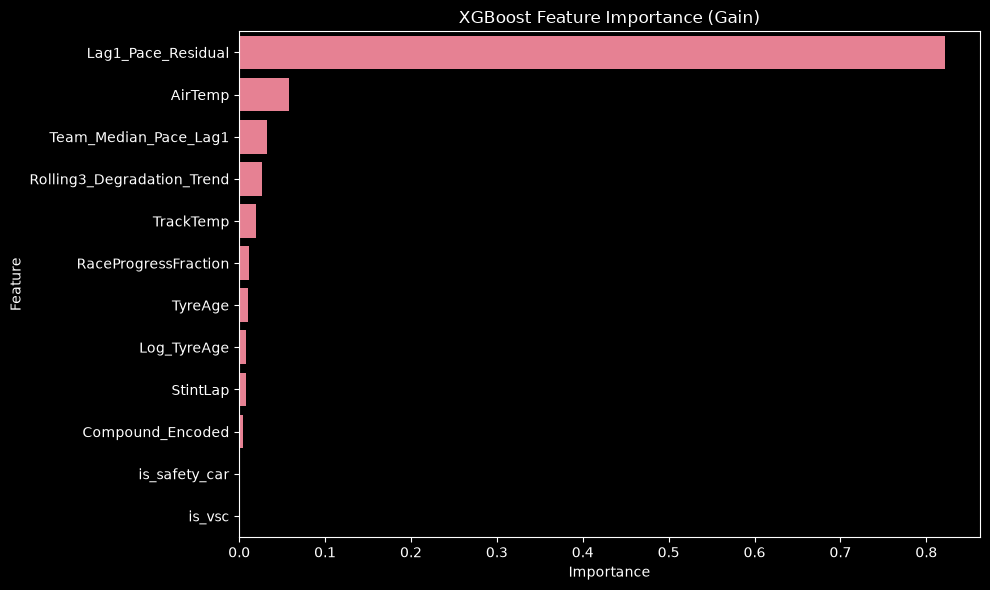

In [5]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title('XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'xgb_feature_importance.png'))
plt.show()

## 5. Extensive Diagnostics (Validation Set)

In [6]:
val_df['Residual'] = val_df['XGB_Pred'] - val_df[target]

# 1. Actual vs Predicted
plt.figure(figsize=(8, 8))
plt.scatter(val_df[target], val_df['XGB_Pred'], alpha=0.2, s=2, color='cyan')
plt.plot([-5, 5], [-5, 5], 'r--')
plt.title('Actual vs Predicted Pace Deficit (Validation)')
plt.xlabel('Actual Target')
plt.ylabel('Predicted Target')
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'actual_vs_predicted.png'))
plt.close()

# 2. Residual Distribution
plt.figure(figsize=(10, 5))
sns.histplot(val_df['Residual'], bins=100, kde=True, color='magenta')
plt.title('Residual Distribution (Pred - Actual)')
plt.xlabel('Error (Seconds)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'residual_distribution.png'))
plt.close()

# 3. Residual vs Tyre Age
plt.figure(figsize=(12, 5))
sns.boxplot(data=val_df[val_df['TyreAge'] <= 30], x='TyreAge', y='Residual')
plt.axhline(0, color='r', linestyle='--')
plt.title('Error (Residuals) by Tyre Age')
plt.xlabel('Tyre Age')
plt.ylabel('Residual (Pred - Actual)')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'residual_vs_tyreage.png'))
plt.close()

# 4. Degradation Trajectory by Stint (Sample)
sample_stints = val_df['StintId'].unique()[:4]
sample_df = val_df[val_df['StintId'].isin(sample_stints)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=sample_df, x='StintLap', y=target, hue='StintId', marker='o', alpha=0.5, legend=False)
sns.lineplot(data=sample_df, x='StintLap', y='XGB_Pred', hue='StintId', linestyle='--', legend=False)
plt.title('Stint Trajectories: Solid=Actual, Dashed=Predicted')
plt.xlabel('Stint Lap')
plt.ylabel('Pace Deficit')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'trajectory_by_stint.png'))
plt.close()

print("Diagnostic plots generated and saved.")

Diagnostic plots generated and saved.


## 6. Output Generation & Final Test Eval

In [7]:
# Final Evaluation on the untouched 2025 Test Set (ONLY the baseline model, to establish the benchmark)
X_test = test_df[features]
y_test = test_df[target]
test_df['XGB_Pred'] = xgb_model.predict(X_test)
test_metrics = evaluate_model('XGBoost Baseline (TEST SET 2025)', y_test, test_df['XGB_Pred'])

final_metrics_df = pd.concat([results_df, pd.DataFrame([test_metrics])], ignore_index=True)
display(final_metrics_df)

# Save metrics
metrics_path = os.path.join(OUTPUT_DIR, "reports", "xgboost_baseline_metrics.csv")
final_metrics_df.to_csv(metrics_path, index=False)

# Save predictions
val_df[['RaceId', 'Driver', 'LapNumber', 'StintId', target, 'XGB_Pred']].to_parquet(os.path.join(OUTPUT_DIR, "predictions", "val_predictions.parquet"), index=False)
test_df[['RaceId', 'Driver', 'LapNumber', 'StintId', target, 'XGB_Pred']].to_parquet(os.path.join(OUTPUT_DIR, "predictions", "test_predictions.parquet"), index=False)

# Save model
model_path = os.path.join(OUTPUT_DIR, "models", "xgboost_baseline.json")
xgb_model.save_model(model_path)

print(f"\nModel saved to: {model_path}")
print(f"Metrics saved to: {metrics_path}")
print("\n[OK] Notebook 08 XGBoost Baseline complete.")

,Model,MAE,RMSE,R2,Bias
0,Global Mean,1.257936,1.714104,-0.077493,-0.459686
1,Linear Reg (TyreAge Only),1.197348,1.633060,0.021987,-0.404808
2,Multiple Linear Reg,0.939714,1.481934,0.194626,-0.000815
3,XGBoost Baseline,0.440426,0.708557,0.815885,0.007545
4,XGBoost Baseline (TEST SET 2025),0.423728,0.718566,0.841078,0.035010



Model saved to: ..\outputs\xgboost_baseline.json
Metrics saved to: ..\outputs\xgboost_baseline_metrics.csv

[OK] Notebook 08 XGBoost Baseline complete.
